In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

# Selected color palatte for this assignment
C_BLUE = "#0072B2"
C_ORANGE = "#E69F00"
C_GREEN = "#009E73"
C_VERMILLION = "#D55E00"
C_GREY = "#666666"

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
np.set_printoptions(suppress=True)


In [ ]:
def generate_building_energy_data(n=1100, seed=42):
    rng = np.random.default_rng(seed)

    day_of_year = rng.integers(1, 366, size=n)
    weekday = rng.integers(0, 7, size=n)
    is_weekend = (weekday >= 5).astype(int)

    outdoor_temp_c = 15 + 11.5 * np.sin(2 * np.pi * (day_of_year - 100) / 365) + rng.normal(0, 2.2, n)

    occupancy_rate = np.where(
        is_weekend == 1,
        np.clip(rng.normal(0.20, 0.06, n), 0.03, 0.45),
        np.clip(rng.normal(0.82, 0.08, n), 0.45, 1.0),
    )

    humidity_pct = np.clip(55 + 0.4 * (outdoor_temp_c - 15) + rng.normal(0, 8, n), 15, 95)
    solar_irradiance_wm2 = np.clip(
        150 + 120 * np.sin(2 * np.pi * (day_of_year - 90) / 365) + rng.normal(0, 30, n), 0, None
    )

    # Relationship of the data
    comfort_point = 18.0
    hvac = 0.85 * (outdoor_temp_c - comfort_point) ** 2          
    occ_load = 60 * occupancy_rate                                
    dehumid = 0.7 * humidity_pct + 3.0 * (humidity_pct / 100) * np.maximum(outdoor_temp_c - 23, 0)
    solar_offset = -0.08 * solar_irradiance_wm2                  
    base_load = 40
    true_energy_kwh = np.clip(base_load + hvac + occ_load + dehumid + solar_offset, 25, None)

    energy_kwh = true_energy_kwh + rng.normal(0, 10, n)

    # outliers finding in the dataset
    u = rng.random(n)
    is_outlier = np.zeros(n, dtype=bool)
    malfunction_mask = u < 0.03
    shutdown_mask = (u >= 0.03) & (u < 0.05)
    energy_kwh[malfunction_mask] *= rng.uniform(1.6, 2.4, malfunction_mask.sum())
    energy_kwh[shutdown_mask] *= rng.uniform(0.25, 0.45, shutdown_mask.sum())
    energy_kwh = np.clip(energy_kwh, 5, None)
    is_outlier[malfunction_mask | shutdown_mask] = True

    df = pd.DataFrame({
        "day_of_year": day_of_year,
        "weekday": weekday,
        "is_weekend": is_weekend,
        "outdoor_temp_c": outdoor_temp_c.round(2),
        "occupancy_rate": occupancy_rate.round(3),
        "humidity_pct": humidity_pct.round(1),
        "solar_irradiance_wm2": solar_irradiance_wm2.round(1),
        "energy_kwh": energy_kwh.round(2),
    })
    return df, true_energy_kwh, is_outlier


df, true_energy_kwh, is_outlier = generate_building_energy_data()
df.to_csv("building_energy_dataset.csv", index=False)
print(f"{df.shape[0]} rows, {is_outlier.sum()} flagged as outliers ({is_outlier.mean():.1%})")
df.head()


1100 rows, 54 flagged as outliers (4.9%)


,day_of_year,weekday,is_weekend,outdoor_temp_c,occupancy_rate,humidity_pct,solar_irradiance_wm2,energy_kwh
0,33,3,0,4.35,0.852,58.5,64.8,291.02
1,283,3,0,12.54,0.600,57.6,152.6,141.13
2,239,6,1,23.83,0.097,57.1,259.7,85.24
3,161,1,0,28.16,0.795,59.2,273.9,200.29
4,159,2,0,24.60,0.755,64.7,289.0,135.20


In [3]:
df.describe().round(2)


,day_of_year,weekday,is_weekend,outdoor_temp_c,occupancy_rate,humidity_pct,solar_irradiance_wm2,energy_kwh
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,184.50,3.03,0.29,14.85,0.64,54.80,151.47,178.18
std,105.42,1.99,0.45,8.43,0.29,8.78,91.16,84.91
min,2.00,0.00,0.00,-2.78,0.06,25.70,0.00,27.10
25%,91.75,1.00,0.00,7.07,0.26,48.98,68.88,118.33
50%,185.00,3.00,0.00,14.76,0.78,54.65,146.55,155.61
75%,277.25,5.00,1.00,22.51,0.85,61.22,234.30,222.07
max,365.00,6.00,1.00,30.64,1.00,82.00,363.60,695.65


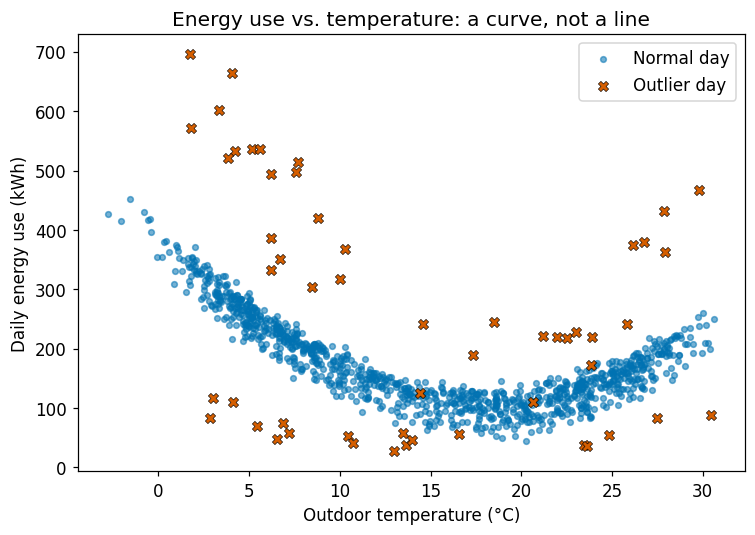

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df.loc[~is_outlier, "outdoor_temp_c"], df.loc[~is_outlier, "energy_kwh"],
           s=14, alpha=0.55, color=C_BLUE, marker="o", label="Normal day")
ax.scatter(df.loc[is_outlier, "outdoor_temp_c"], df.loc[is_outlier, "energy_kwh"],
           s=45, color=C_VERMILLION, marker="X", edgecolor="black", linewidth=0.4, label="Outlier day")
ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("Daily energy use (kWh)")
ax.set_title("Energy use vs. temperature: a curve, not a line")
ax.legend()
fig.tight_layout()
plt.show()


There's a clear U-shape which means that energy use is high when it's cold, dips to a minimum somewhere in the highs, then climbs again as it gets hot. On top of that curve sit a number of points (marked with an X) which are outliers, the malfunction and closure days, scattered well above and below the main band.

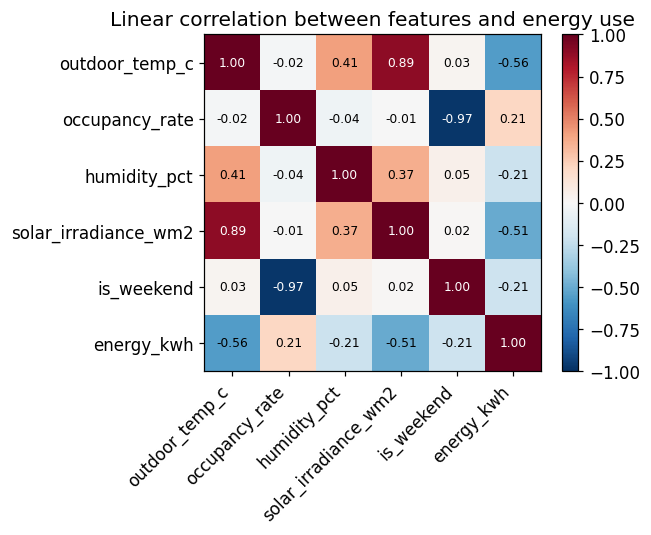

In [5]:
corr = df[["outdoor_temp_c", "occupancy_rate", "humidity_pct", "solar_irradiance_wm2", "is_weekend", "energy_kwh"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Linear correlation between features and energy use")
fig.tight_layout()
plt.show()


Temperature only shows a moderate *linear* correlation with energy use (around −0.6), which understates how strong the actual relationship is.

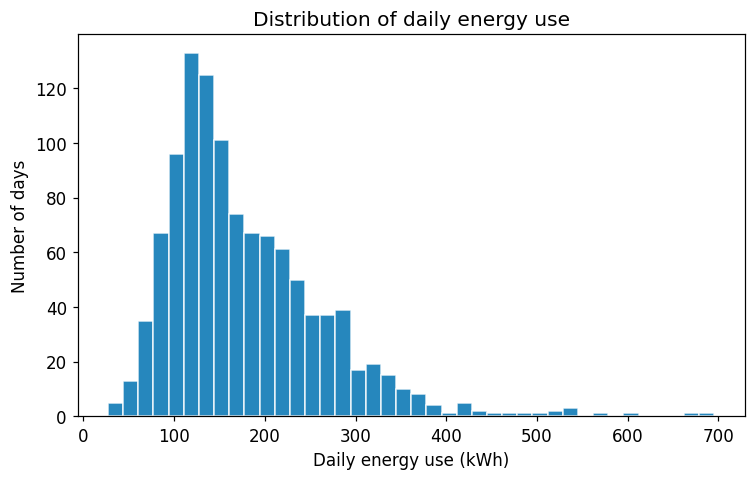

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["energy_kwh"], bins=40, color=C_BLUE, alpha=0.85, edgecolor="white")
ax.set_xlabel("Daily energy use (kWh)")
ax.set_ylabel("Number of days")
ax.set_title("Distribution of daily energy use")
fig.tight_layout()
plt.show()


Most days sit in a fairly tight band, but there's a long right tail stretching out past 200 kWh

In [7]:
feature_cols = ["outdoor_temp_c", "occupancy_rate", "humidity_pct", "solar_irradiance_wm2", "is_weekend"]
X = df[feature_cols].values
y_observed = df["energy_kwh"].values

idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.25, random_state=7)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test_observed = y_observed[idx_train], y_observed[idx_test]
y_test_true = true_energy_kwh[idx_test]
test_outlier_mask = is_outlier[idx_test]

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(f"Linear Regression vs. true signal:  MAE = {mean_absolute_error(y_test_true, lr_pred):.2f} kWh,  "
      f"R² = {r2_score(y_test_true, lr_pred):.3f}")


Linear Regression vs. true signal:  MAE = 45.63 kWh,  R² = 0.493


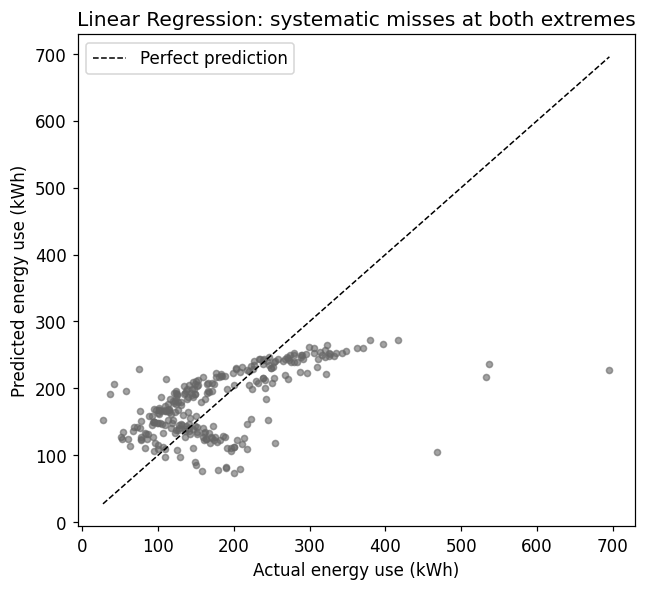

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(y_test_observed, lr_pred, s=16, alpha=0.6, color=C_GREY)
lims = [min(y_test_observed.min(), lr_pred.min()), max(y_test_observed.max(), lr_pred.max())]
ax.plot(lims, lims, "--", color="black", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual energy use (kWh)")
ax.set_ylabel("Predicted energy use (kWh)")
ax.set_title("Linear Regression: systematic misses at both extremes")
ax.legend()
fig.tight_layout()
plt.show()


An R² of roughly 0.5 against the true signal, and a scatter plot that flattens out instead of following the diagonal: the model can't predict above about 270 kWh no matter how extreme the actual value gets, because it's only allowed to draw one straight line through a relationship that bends in two different directions.

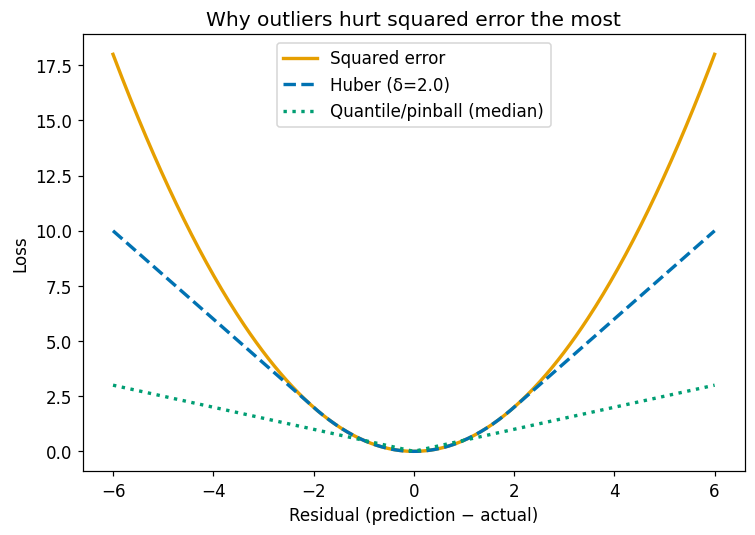

In [9]:
resid = np.linspace(-6, 6, 400)
squared_loss = 0.5 * resid ** 2
delta = 2.0
huber_loss = np.where(np.abs(resid) <= delta, 0.5 * resid ** 2, delta * (np.abs(resid) - 0.5 * delta))
pinball_loss = np.where(resid >= 0, 0.5 * resid, -0.5 * resid)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(resid, squared_loss, color=C_ORANGE, linewidth=2.2, label="Squared error")
ax.plot(resid, huber_loss, color=C_BLUE, linewidth=2.2, linestyle="--", label=f"Huber (δ={delta})")
ax.plot(resid, pinball_loss, color=C_GREEN, linewidth=2.2, linestyle=":", label="Quantile/pinball (median)")
ax.set_xlabel("Residual (prediction − actual)")
ax.set_ylabel("Loss")
ax.set_title("Why outliers hurt squared error the most")
ax.legend()
fig.tight_layout()
plt.show()


At small residuals the three curves are nearly identical, the loss function barely matters. The gap only opens up out at the edges. A genuinely extreme point lets say residual = 6 contributes 18 units of squared-error loss but only 10 under Huber and just 3 under quantile loss. Since every tree in the ensemble is built to reduce the current loss, a training set with even a handful of these extreme points will quietly steer a squared-error model toward accommodating them at the cost of fitting everything else slightly worse.

In [10]:
common_kwargs = dict(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=0)

def fit_and_eval(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "Model": name,
        "MAE vs observed": round(mean_absolute_error(y_test_observed, pred), 2),
        "R2 vs observed": round(r2_score(y_test_observed, pred), 3),
        "MAE vs true signal": round(mean_absolute_error(y_test_true, pred), 2),
        "R2 vs true signal": round(r2_score(y_test_true, pred), 3),
    }, pred

results = []
res, _ = fit_and_eval("Linear Regression", LinearRegression())
results.append(res)
res, pred_se = fit_and_eval("Gradient Boosting (squared error)", GradientBoostingRegressor(loss="squared_error", **common_kwargs))
results.append(res)
res, pred_huber = fit_and_eval("Gradient Boosting (Huber, α=0.9)", GradientBoostingRegressor(loss="huber", alpha=0.9, **common_kwargs))
results.append(res)
res, pred_quant = fit_and_eval("Gradient Boosting (Quantile, median)", GradientBoostingRegressor(loss="quantile", alpha=0.5, **common_kwargs))
results.append(res)

results_df = pd.DataFrame(results)
results_df


,Model,MAE vs observed,R2 vs observed,MAE vs true signal,R2 vs true signal
0,Linear Regression,52.98,0.351,45.63,0.493
1,Gradient Boosting (squared error),22.89,0.713,11.14,0.926
2,"Gradient Boosting (Huber, α=0.9)",18.60,0.755,5.96,0.984
3,"Gradient Boosting (Quantile, median)",18.88,0.754,6.38,0.984


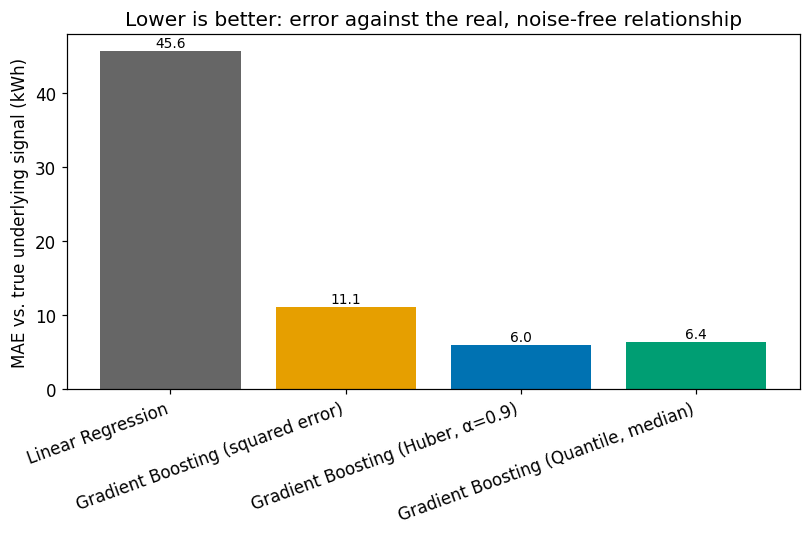

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))
colors = [C_GREY, C_ORANGE, C_BLUE, C_GREEN]
bars = ax.bar(results_df["Model"], results_df["MAE vs true signal"], color=colors)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df["Model"], rotation=20, ha="right")
ax.set_ylabel("MAE vs. true underlying signal (kWh)")
ax.set_title("Lower is better: error against the real, noise-free relationship")
for b, v in zip(bars, results_df["MAE vs true signal"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()


Every gradient boosting variant beats linear regression by a wide margin, which is the expected, less interesting result. The more useful comparison is between the three boosting variants themselves: switching from squared error to Huber loss roughly halves the error against the true signal, and quantile loss lands close behind. All three models were trained on exactly the same labels, the only thing that changed was which statistic each tree was told to chase.

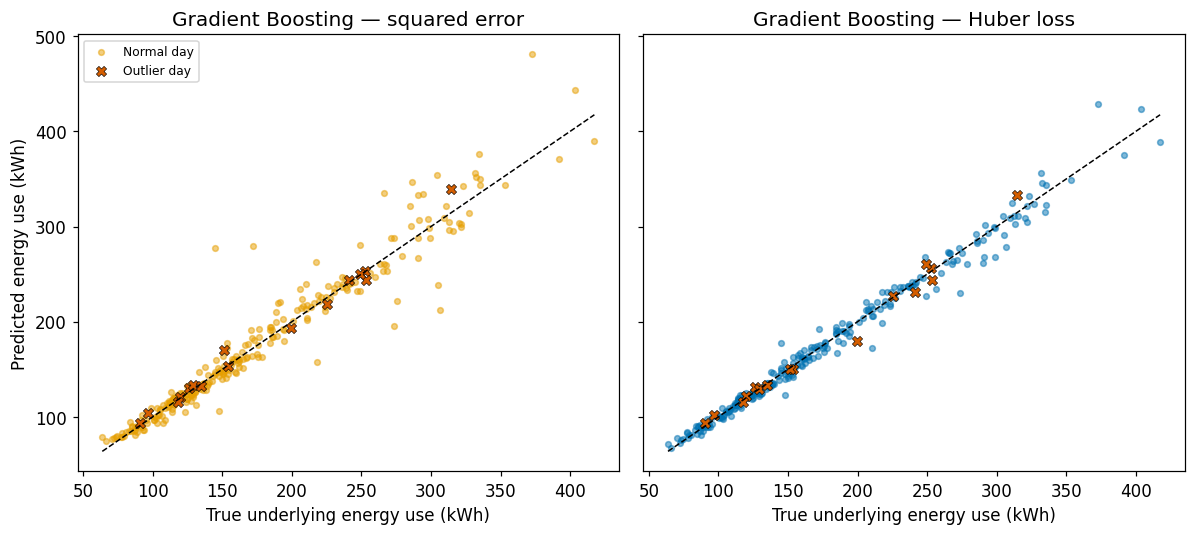

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, pred, title, color in zip(
    axes, [pred_se, pred_huber],
    ["Gradient Boosting — squared error", "Gradient Boosting — Huber loss"],
    [C_ORANGE, C_BLUE],
):
    ax.scatter(y_test_true[~test_outlier_mask], pred[~test_outlier_mask], s=14, alpha=0.5, color=color, label="Normal day")
    ax.scatter(y_test_true[test_outlier_mask], pred[test_outlier_mask], s=45, color=C_VERMILLION, marker="X",
               edgecolor="black", linewidth=0.4, label="Outlier day")
    lims = [y_test_true.min(), y_test_true.max()]
    ax.plot(lims, lims, "--", color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("True underlying energy use (kWh)")
axes[0].set_ylabel("Predicted energy use (kWh)")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


The Huber panel hugs the diagonal noticeably more tightly than the squared-error panel, including on points that have nothing to do with the outliers at all. That's the mechanism showing up directly in the output: a handful of bad rows in training inflated the squared-error loss so much that the model shifted to partially accommodate them, at the expense of accuracy everywhere else.


In [13]:
seed_results = []
for split_seed in range(1, 9):
    idx_tr, idx_te = train_test_split(idx, test_size=0.25, random_state=split_seed)
    Xtr, Xte = X[idx_tr], X[idx_te]
    ytr = y_observed[idx_tr]
    ytrue_te = true_energy_kwh[idx_te]

    m_se = GradientBoostingRegressor(loss="squared_error", **common_kwargs).fit(Xtr, ytr)
    m_hub = GradientBoostingRegressor(loss="huber", alpha=0.9, **common_kwargs).fit(Xtr, ytr)

    seed_results.append({
        "split_seed": split_seed,
        "squared_error_MAE": round(mean_absolute_error(ytrue_te, m_se.predict(Xte)), 2),
        "huber_MAE": round(mean_absolute_error(ytrue_te, m_hub.predict(Xte)), 2),
    })

seed_df = pd.DataFrame(seed_results)
wins = (seed_df["huber_MAE"] < seed_df["squared_error_MAE"]).sum()
print(f"Huber loss beats squared error on {wins} / {len(seed_df)} splits tried")
seed_df


Huber loss beats squared error on 8 / 8 splits tried


,split_seed,squared_error_MAE,huber_MAE
0,1,9.07,5.75
1,2,13.42,6.36
2,3,11.34,6.46
3,4,9.81,5.29
4,5,14.19,6.60
5,6,12.65,6.60
6,7,11.14,5.96
7,8,13.29,7.51


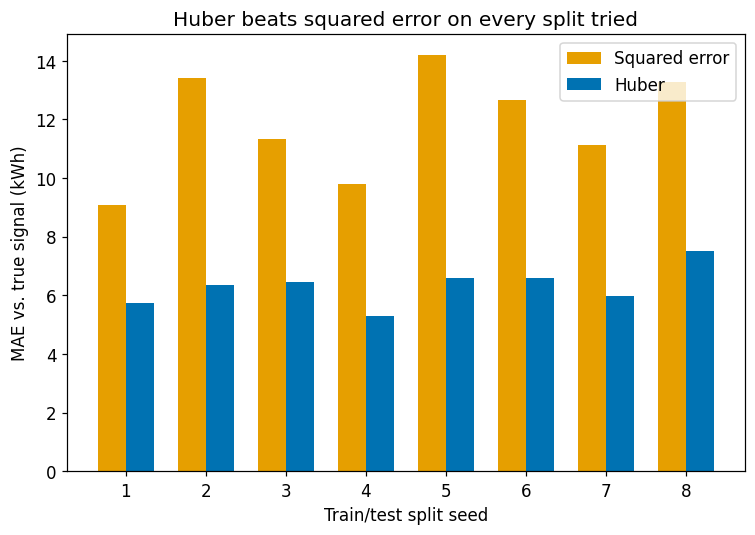

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
x_pos = np.arange(len(seed_df))
width = 0.35
ax.bar(x_pos - width / 2, seed_df["squared_error_MAE"], width, color=C_ORANGE, label="Squared error")
ax.bar(x_pos + width / 2, seed_df["huber_MAE"], width, color=C_BLUE, label="Huber")
ax.set_xticks(x_pos)
ax.set_xticklabels(seed_df["split_seed"])
ax.set_xlabel("Train/test split seed")
ax.set_ylabel("MAE vs. true signal (kWh)")
ax.set_title("Huber beats squared error on every split tried")
ax.legend()
fig.tight_layout()
plt.show()


Huber wins on all eight splits, by a comparable margin each time. That's enough to treat this as a real effect of the loss function rather than an artefact of one particular train/test split.


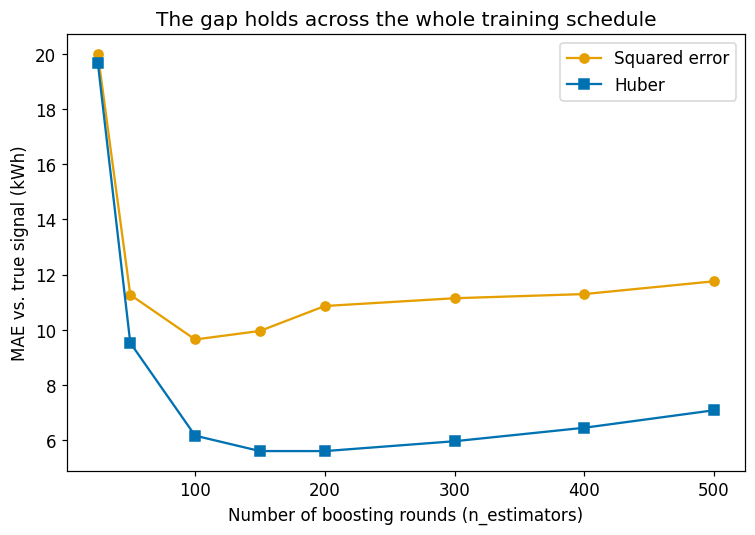

In [15]:
n_range = [25, 50, 100, 150, 200, 300, 400, 500]
mae_se_list, mae_huber_list = [], []
for n in n_range:
    m_se = GradientBoostingRegressor(loss="squared_error", n_estimators=n, max_depth=3, learning_rate=0.05, random_state=0)
    m_se.fit(X_train, y_train)
    mae_se_list.append(mean_absolute_error(y_test_true, m_se.predict(X_test)))

    m_hub = GradientBoostingRegressor(loss="huber", alpha=0.9, n_estimators=n, max_depth=3, learning_rate=0.05, random_state=0)
    m_hub.fit(X_train, y_train)
    mae_huber_list.append(mean_absolute_error(y_test_true, m_hub.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_range, mae_se_list, marker="o", color=C_ORANGE, label="Squared error")
ax.plot(n_range, mae_huber_list, marker="s", color=C_BLUE, label="Huber")
ax.set_xlabel("Number of boosting rounds (n_estimators)")
ax.set_ylabel("MAE vs. true signal (kWh)")
ax.set_title("The gap holds across the whole training schedule")
ax.legend()
fig.tight_layout()
plt.show()


Two things stand out. First, Huber sits below squared error at every single value of `n_estimators` tried, it's consistent across the whole training schedule. Second, both curves dip to a minimum somewhere around 100–150 trees and then climb back up with more boosting rounds. That's overfitting, as with enough additive trees and a small, fixed learning rate, the model eventually starts fitting the outliers more precisely, which hurts its match to the true signal even as it keeps improving on the training data.

In [16]:
gbr_early = GradientBoostingRegressor(
    loss="huber", alpha=0.9, max_depth=3, learning_rate=0.05,
    n_estimators=1000, validation_fraction=0.15, n_iter_no_change=15, tol=1e-4, random_state=0,
)
gbr_early.fit(X_train, y_train)
pred_early = gbr_early.predict(X_test)

print(f"Stopped automatically at {gbr_early.n_estimators_} trees (cap was set to 1000)")
print(f"MAE vs. true signal: {mean_absolute_error(y_test_true, pred_early):.2f} kWh")


Stopped automatically at 227 trees (cap was set to 1000)
MAE vs. true signal: 6.28 kWh


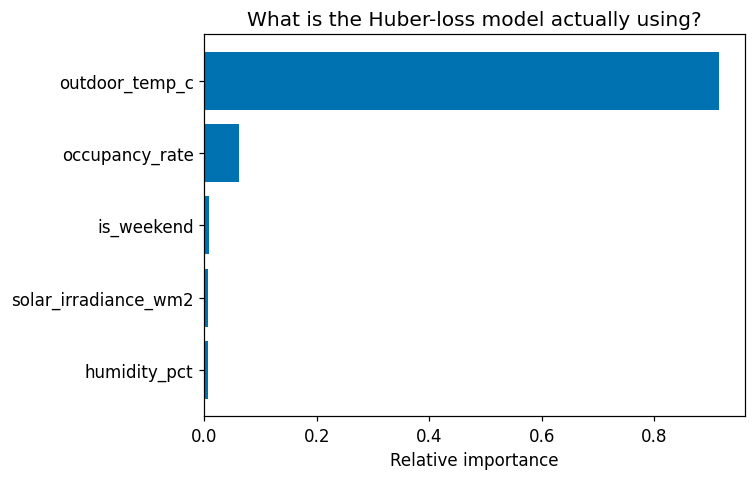

In [17]:
huber_model = GradientBoostingRegressor(loss="huber", alpha=0.9, **common_kwargs)
huber_model.fit(X_train, y_train)
importances = huber_model.feature_importances_
order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(np.array(feature_cols)[order], importances[order], color=C_BLUE)
ax.set_xlabel("Relative importance")
ax.set_title("What is the Huber-loss model actually using?")
fig.tight_layout()
plt.show()


Outdoor temperature dominates, it drives the heating/cooling load directly. Occupancy comes in a distant second, and the remaining features barely register.

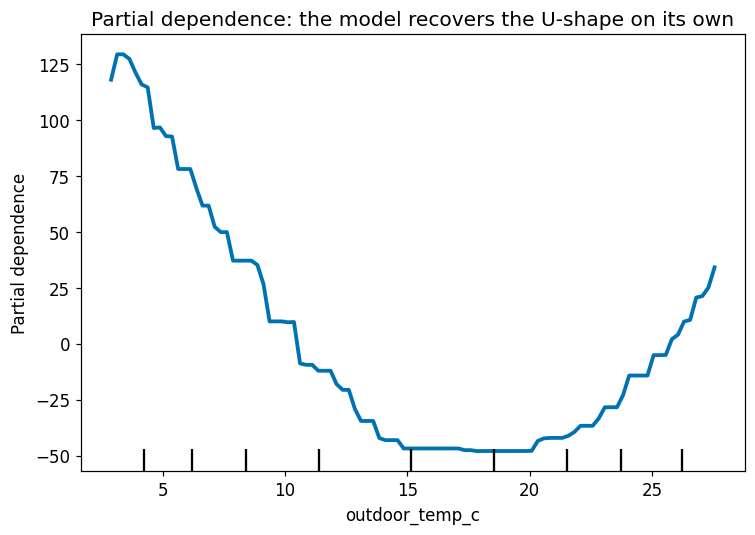

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    huber_model, X_train, features=[0], feature_names=feature_cols, ax=ax,
    line_kw={"color": C_BLUE, "linewidth": 2.5},
)
ax.set_title("Partial dependence: the model recovers the U-shape on its own")
ax.set_xlabel("Outdoor temperature (°C)")
fig.tight_layout()
plt.show()


The curve the model produces bottoms out in roughly the high-tens range which is close to the comfort point of 18°C and rises on both sides as temperature moves away from it in either direction. Nothing about the feature encoding hinted at a "comfort point", the trees recovered the shape purely from how energy use varied with temperature in the training data.